# Regression and In-Between Uncertainty

This notebook illustrates IVON on a simple regression problem, showing how it can capture uncertainty in regions with little date.

In [1]:
import torch
import matplotlib.pyplot as plt
import math
from ivon import IVON

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

Create and visualize the dataset.

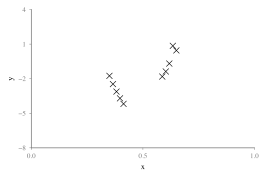

In [2]:
def make_toy_data(n=20):
    std = torch.logspace(-3, 0, n)
    x = torch.linspace(0.35, 0.65, n)
    y = 5 * torch.sin(10 * x) + std * torch.randn_like(x)

    # Keep only the first and last 5 points
    x = torch.cat((x[:5], x[-5:]))
    y = torch.cat((y[:5], y[-5:]))

    return x[:, None], y[:, None]


def plot_data(X, y, yl=None):
    fig, ax = plt.subplots(figsize=(4, 2.5))

    ax.plot(X.squeeze(), y.squeeze(), 'x', color='black', markeredgewidth=0.6)

    ax.set(
        xlabel='x',
        ylabel='y',
        xlim=(0, 1),
        ylim=yl,
        xticks=torch.linspace(0, 1, 3),
        yticks=torch.linspace(yl[0], yl[1], 5),
    )

    return fig, ax


torch.manual_seed(42)
X, y = make_toy_data()
fig, ax = plot_data(X, y, yl=(-8, 4))

Train a MLP with IVON.

In [9]:
def make_model():
    hidden = 64
    nonlin = torch.nn.ELU()
    m = torch.nn.Sequential(
        torch.nn.Linear(1, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, 1),
    )

    return m


model = make_model()

# for ess, try out:
# - 1e6 (almost static weights),
# - 1e5 to 1e4 (good trade-off)
# - 1e3 (very noisy weights)
opt = IVON(
    model.parameters(), 
    lr=0.02, 
    ess=1e6, 
    weight_decay=1e-4, 
    hess_init=0.01, 
    beta1=0.9,
    beta2=0.9995, 
    clip_radius=0.1,
    rescale_lr=False
)

loss_fn = torch.nn.MSELoss()
n_steps = 5000
sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt,
    T_max=n_steps,
    eta_min=0.0,
)

for _ in range(n_steps + 1):
    with opt.sampled_params(train=True):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()

    opt.step()
    sched.step()

Visualize the resulting uncertainty.

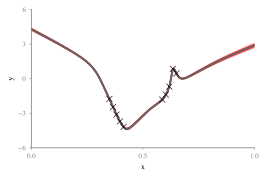

In [10]:
x_eval = torch.linspace(0, 1, 500)[:, None]

with torch.no_grad():
    y_mean = model(x_eval).squeeze()

ys = []
with torch.no_grad():
    for _ in range(200):
        with opt.sampled_params(train=False):
            ys.append(model(x_eval).squeeze())
ys = torch.stack(ys)

xe = x_eval.squeeze()
yl = (math.floor(y_mean.min() - 1), math.ceil(y_mean.max() + 1))

fig, ax = plot_data(X, y, yl=yl)
ax.plot(xe, ys.T, c='red', alpha=0.04, lw=1, zorder=-2)
ax.plot(xe, y_mean, c='0.4', lw=2, zorder=-1);